# Bước 1: Nhập và tiền xử lý ảnh

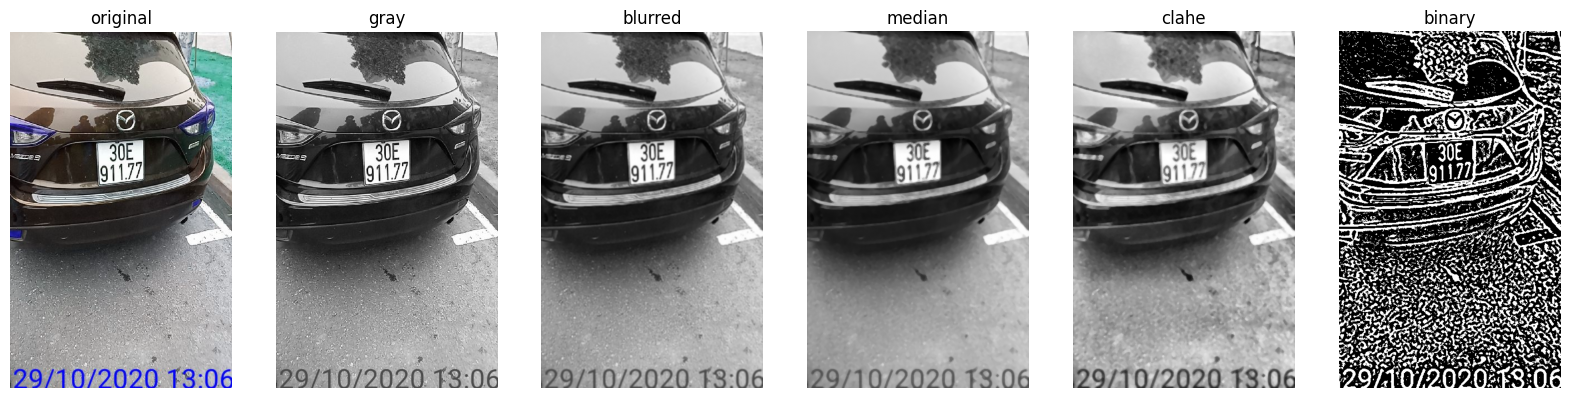

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Hàm để hiển thị hình ảnh
def display_image(images, titles):
    plt.figure(figsize=(20,10))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()
def load_and_preprocess(image_path):
    # 1. Tải ảnh
    original_image = cv2.imread(image_path)
    if original_image is None:
        print("Lỗi: Không thể tải ảnh.")
    else:
        # 2. Tiền xử lý 
        # Chuyển đổi sang ảnh xám
        gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
        # Gaussian Blur để giảm nhiễu
        blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
        # Median Filter để giảm nhiễu nhiều hơn
        median_image = cv2.medianBlur(blurred_image, 5)
        # CLAHE để tăng cường độ tương phản
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        clahe_image = clahe.apply(median_image)
        # Binarization để phát hiện contours (Dùng method Adaptive Thresholding)
        binary_image = cv2.adaptiveThreshold(
            clahe_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, 11, 2
        )
        # 3. Trả về một dictionary để dễ dàng truy cập các bước
        return {
            "original": original_image,
            "gray": gray_image,
            "blurred": blurred_image,
            "median": median_image,
            "clahe": clahe_image,
            "binary": binary_image
        }
# Test 
image_path = r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_91177_checkin_2020-10-29-13-6OyGuWtJecr.jpg'
process_images = load_and_preprocess(image_path)
if process_images:
    display_image(list(process_images.values()), list(process_images.keys()))

# Bước 2 - 3: Phát hiện biển số xe bằng Canny Edge và Morphology


## Tạo hàm `detect_license_plate()`:
1. Tìm cạnh (Canny)
2. Đóng các khoảng trống (Phép đóng)
3. Loại bỏ nhiễu nhỏ (Phép mở)
4. Tìm đường viền (contours)
5. Lọc ra các đường viền phù hợp là biển số xe
6. In và Test

✓ Phát hiện 0 vùng biển số


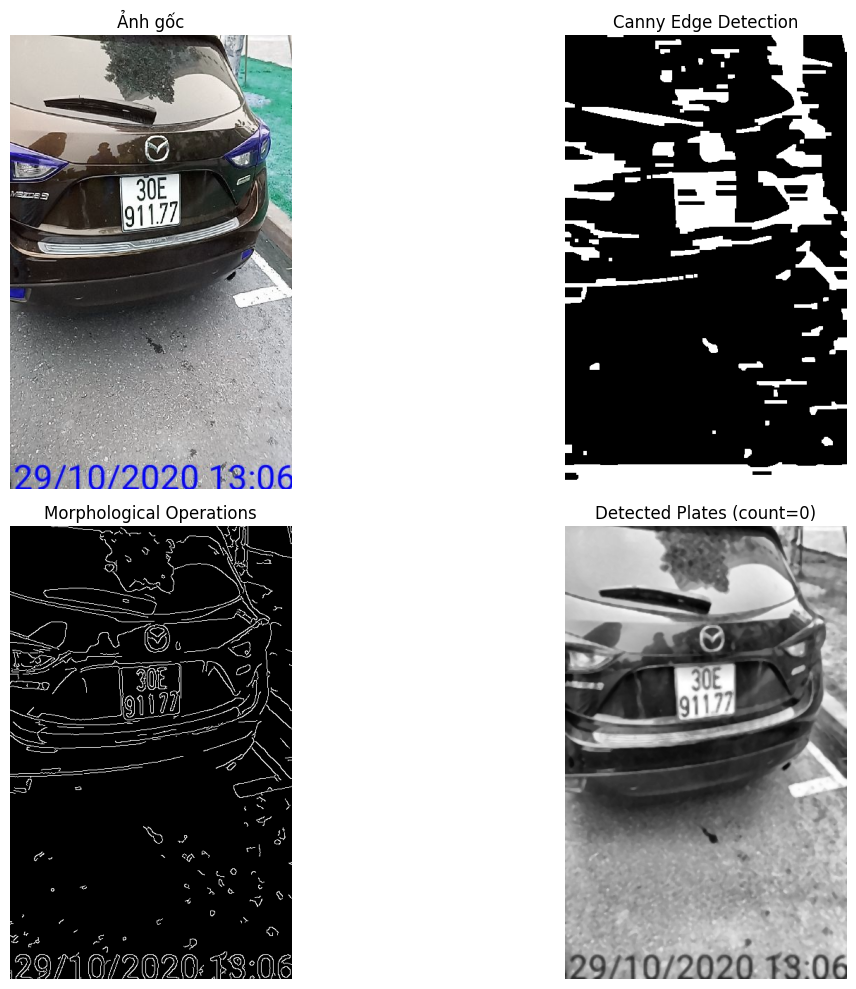

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_license_plate(image_preprocessed, canny_threshold1 = 100, canny_threshold2 = 200, 
                         min_area = 5000, aspect_ratio_range = (1.0, 2.5)):
    # 1. Phát hiện cạnh sử dụng Canny
    edges = cv2.Canny(image_preprocessed, canny_threshold1, canny_threshold2)
    
    # 2. Sử dụng Morphology để đóng các khoảng trống (phép đóng để nối các cạnh thành vùng liên tục)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    
    # 3. Phép mở để loại bỏ nhiễu nhỏ
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    # 4. Tìm contours
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 5. Lọc contours dựa trên diện tích và tỷ lệ khung hình
    plates = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # kiểm tra điều kiện diện tích và tỷ lệ khung hình
        if (area >= min_area and 
            aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            plates.append((x, y, w, h))
    return plates, morph, edges

# Test
detected_plates, edges_img, morph_img = detect_license_plate(process_images['clahe'])

print(f"✓ Phát hiện {len(detected_plates)} vùng biển số")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: vị trí=({x}, {y}), kích thước=({w}x{h}), tỷ lệ={w/h:.2f}")

# Visualize kết quả
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ảnh gốc
axes[0, 0].imshow(process_images['original'], cmap='gray')
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Ảnh Canny edges
axes[0, 1].imshow(edges_img, cmap='gray')
axes[0, 1].set_title('Canny Edge Detection')
axes[0, 1].axis('off')

# Ảnh sau morphology
axes[1, 0].imshow(morph_img, cmap='gray')
axes[1, 0].set_title('Morphological Operations')
axes[1, 0].axis('off')

# Ảnh gốc với bounding boxes
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in detected_plates:
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Tinh chỉnh và nâng cấp hàm `detect_license_plate` với **Adaptive Threshold** & **Geometric Filters**
---
1. Tính tự động ngưỡng Canny bằng **Median-based adaptive**
2. Giữ nguyên các bước xử lý
3. Sau khi tìm contours sẽ áp dụng Geometric Filtering:
    - Diện tích 
    - Tỷ lệ khung hình 
    - Độ "đặc" 
    - Khoảng cách từ cạnh ảnh
4. Tiếp tục cải tiến Adaptive Area & Kernel Size
5. In và Test

In [ ]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

def auto_canny (image, sigma = 0.33):
    """
    Tính Canny thresholds tự động dựa trên median pixel value
    Phương pháp: Median-based Adaptive Thresholding (sử dụng Heuristic)
    Ý tưởng: Giả định các cạnh quan trọng trong ảnh sẽ có gradients cỡ median
    """
    # Tính median pixel value
    v = np.median(image)
    
    # Áp dụng sigma để tính lower và upper thresholds
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    
    return lower, upper
def detect_license_plate_v2(image_preprocessed,
                            sigma = 0.33,
                            min_area = 5000,
                            max_area = 50000,
                            aspect_ratio_range=(0.8, 3.5),
                            min_solidity = 0.5,
                            debug=False):
    """
    Args:
        image_preprocessed: Ảnh đã qua tiền xử lý (CLAHE)
        sigma: Hệ số Heuristic để tính Canny
        min_area, max_area:  Khoảng diện tích contour hợp lệ
        aspect_ratio_range: Khoảng W/H (nới lỏng để có nhiều trường hợp).
        min_solidity: Mức độ "đặc" của contour (0-1, cao = hình dạng rõ ràng)
        debug: In thông tin chi tiết
    Returns:
        plates: Danh sách bounding boxes của biển số được phát hiện
        debug_info: Dictionary chứa intermediate images & stats
    """
    # 1. Tính ngưỡng Canny tự động
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma = sigma)
    if debug:
        print(f"✓ Auto Canny thresholds: lower={lower_canny}, upper={upper_canny}")
    
    # 2. Phát hiện cạnh 
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    # 3. Xử lý hình thái (Morphology)
    # Phép đóng: nối các cạnh thành vùng liên tục
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    
    # Phép mở: loại bỏ nhiễu nhỏ
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)   
    
    # 4. Tìm contours
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 5. Lọc Geometric 
    plates = []
    rejected_stats = {"area":0, "aspect_ratio":0, "solidity":0, "margin":0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # Lọc 1: Diện tích
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # Lọc 2: Tỷ lệ khung hình (W/H)
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # Lọc 3: Độ "đặc" (solidity)
        # Solidity = Area / Convex Hull Area
        # Giá trị cao = hình dạng đặc (ít có lỗ), thấp = rỗng hoặc nhiễu
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # Lọc 4: Khoảng cách từ cạnh ảnh (Tránh detect phần xe)
        margin = 10
        if x <= margin or y <= margin or (x + w) >= (image_preprocessed.shape[1] - margin) or (y + h) >= (image_preprocessed.shape[0] - margin):
            rejected_stats["margin"] += 1
            continue
        
        # Nếu vượt qua tất cả các bộ lọc, thêm vào danh sách plates
        plates.append((x, y, w, h))
        
        if debug:
            print(f"✓ Detected plate: pos=({x}, {y}), size=({w}x{h}), area={area}, aspect_ratio={aspect_ratio:.2f}, solidity={solidity:.2f}")
    # DEBUG INFO
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": len(contours),
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    if debug:
        print(f"\n📈 Tổng kết:")
        print(f"  • Tìm được {len(contours)} contours")
        print(f"  • Bị từ chối (diện tích): {rejected_stats['area']}")
        print(f"  • Bị từ chối (tỷ lệ): {rejected_stats['aspect_ratio']}")
        print(f"  • Bị từ chối (solidity): {rejected_stats['solidity']}")
        print(f"  • Bị từ chối (margin): {rejected_stats['margin']}")
        print(f"  • ✅ Phát hiện {len(plates)} biển số hợp lệ")
    return plates, debug_info
detect_license_plate_v2(process_images['clahe'], debug=True)

✓ Auto Canny thresholds: lower=60, upper=119
✓ Detected plate: pos=(55, 337), size=(190x102), area=12993.5, aspect_ratio=1.86, solidity=0.92

📈 Tổng kết:
  • Tìm được 67 contours
  • Bị từ chối (diện tích): 65
  • Bị từ chối (tỷ lệ): 1
  • Bị từ chối (solidity): 0
  • ✅ Phát hiện 1 biển số hợp lệ


([(55, 337, 190, 102)],
 {'edges': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(644, 400), dtype=uint8),
  'morph': array([[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]], shape=(644, 400), dtype=uint8),
  'contours': 67,
  'canny_lower': 60,
  'canny_upper': 119,
  'rejected': {'area': 65, 'aspect_ratio': 1, 'solidity': 0},
  'plates_count': 1})

📐 Image dimensions: 400x644, area=257600
   Adaptive area range: 5152-38640 (2.0%-15.0%)
📊 Auto Canny Thresholds: lower=60, upper=119
🔧 Adaptive kernel: close_kernel=(41, 13)

📈 Tổng kết:
  • Tìm được 18 contours
  • Bị từ chối (diện tích): 17
  • Bị từ chối (tỷ lệ): 0
  • Bị từ chối (solidity): 0
  • ✅ Phát hiện 0 biển số hợp lệ

✓ Phát hiện 0 vùng biển số


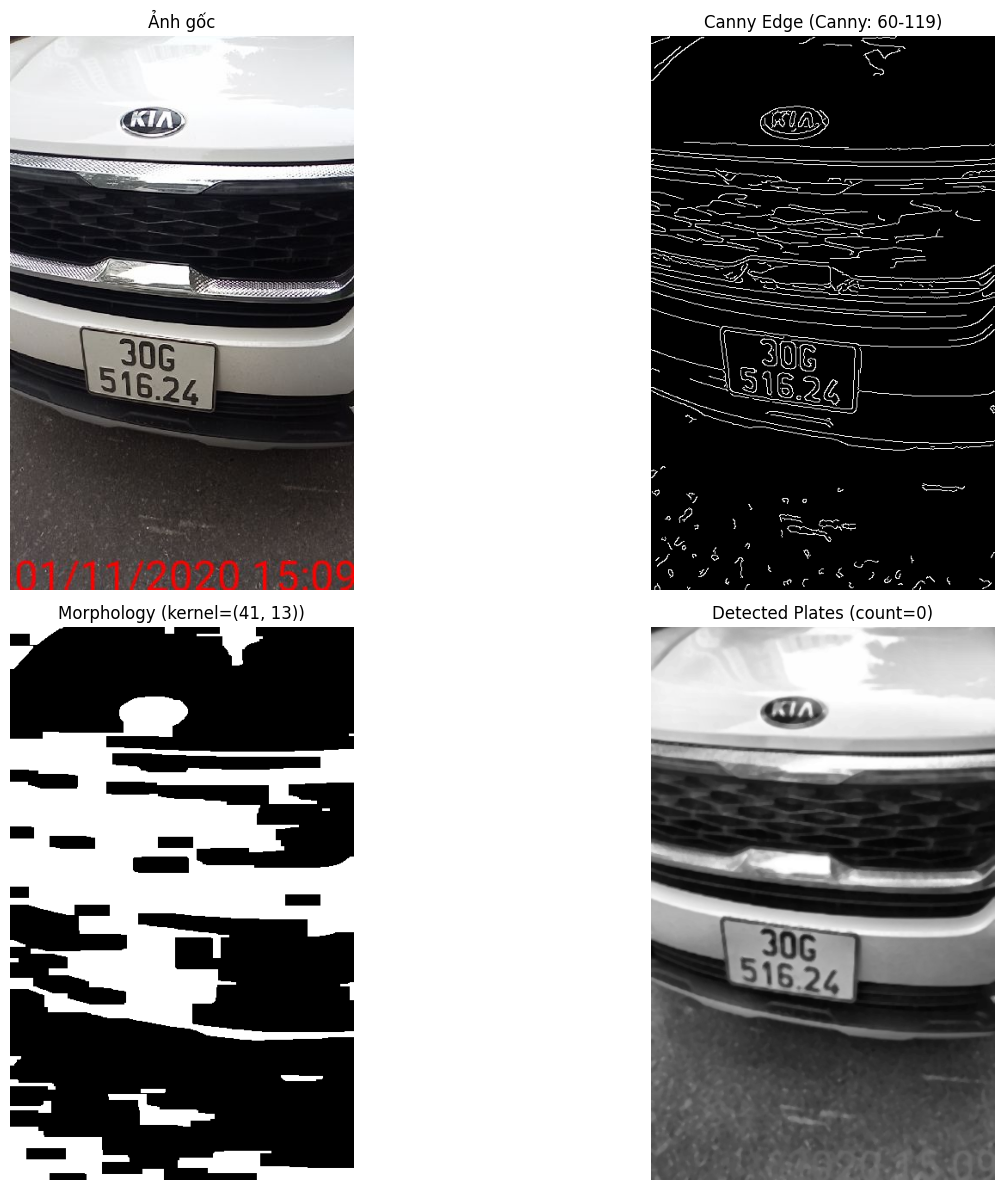

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def auto_canny(image, sigma=0.33):
    """
    Tính tự động Canny thresholds dựa trên median pixel value.
    """
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return lower, upper

def detect_license_plate_v3(image_preprocessed,
                             sigma=0.33,
                             area_ratio_range=(0.02, 0.15),  # 2%-15% của diện tích ảnh
                             aspect_ratio_range=(0.8, 3.5),
                             min_solidity=0.5,
                             kernel_width_ratio=0.1,  # 10% chiều rộng ảnh
                             kernel_height_ratio=0.02, # 2% chiều cao ảnh
                             debug=False):
    """
    Phát hiện biển số với Adaptive Parameters (tỷ lệ % diện tích ảnh).
    
    Args:
        image_preprocessed: Ảnh grayscale đã tiền xử lý (CLAHE)
        sigma: Hệ số điều chỉnh Canny
        area_ratio_range: Tuple(min%, max%) - % diện tích ảnh (tỷ lệ 0-1)
                         VD: (0.02, 0.15) = 2%-15% diện tích ảnh
        aspect_ratio_range: Khoảng W/H của biển số
        min_solidity: Mức độ "đặc" của contour (0-1)
        kernel_width_ratio: % chiều rộng ảnh để tính kernel width (VD: 0.1 = 10%)
        kernel_height_ratio: % chiều cao ảnh để tính kernel height (VD: 0.02 = 2%)
        debug: In thông tin chi tiết
    
    Returns:
        plates: List[(x, y, w, h)] - bounding boxes
        debug_info: Dictionary chứa intermediate images & statistics
    """
    
    img_height, img_width = image_preprocessed.shape
    img_area = img_height * img_width
    
    # ========== 1. ADAPTIVE AREA THRESHOLDS (dựa trên % diện tích ảnh) ==========
    min_area = int(img_area * area_ratio_range[0])
    max_area = int(img_area * area_ratio_range[1])
    
    if debug:
        print(f"📐 Image dimensions: {img_width}x{img_height}, area={img_area}")
        print(f"   Adaptive area range: {min_area}-{max_area} ({area_ratio_range[0]*100:.1f}%-{area_ratio_range[1]*100:.1f}%)")
    
    # ========== 2. AUTO CANNY THRESHOLDS ==========
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma=sigma)
    if debug:
        print(f"📊 Auto Canny Thresholds: lower={lower_canny}, upper={upper_canny}")
    
    # ========== 3. CANNY EDGE DETECTION ==========
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    # ========== 4. ADAPTIVE MORPHOLOGICAL OPERATIONS ==========
    # Tính kích thước kernel dựa trên kích thước ảnh
    kernel_width = max(5, int(img_width * kernel_width_ratio))
    kernel_height = max(3, int(img_height * kernel_height_ratio))
    
    # Đảm bảo kernel có kích thước lẻ (required by OpenCV)
    if kernel_width % 2 == 0:
        kernel_width += 1
    if kernel_height % 2 == 0:
        kernel_height += 1
    
    if debug:
        print(f"🔧 Adaptive kernel: close_kernel=({kernel_width}, {kernel_height})")
    
    # Close kernel: nối các cạnh thành vùng liên tục
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, kernel_height))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    
    # Open kernel: loại bỏ nhiễu nhỏ (nhỏ hơn close kernel)
    kernel_open_w = max(3, kernel_width // 5)
    kernel_open_h = max(3, kernel_height // 5)
    if kernel_open_w % 2 == 0:
        kernel_open_w += 1
    if kernel_open_h % 2 == 0:
        kernel_open_h += 1
    
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_open_w, kernel_open_h))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    # ========== 5. FIND CONTOURS ==========
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # ========== 6. GEOMETRIC FILTERING ==========
    plates = []
    rejected_stats = {"area": 0, "aspect_ratio": 0, "solidity": 0, "margin": 0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # **Filter 1: Diện tích (adaptive dựa % ảnh)**
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # **Filter 2: Tỷ lệ khung hình (W/H)**
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # **Filter 3: Solidity (độ "đặc" của contour)**
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # **Filter 4: Khoảng cách từ cạnh ảnh**
        margin = max(5, int(img_width * 0.05))  # 5% chiều rộng hoặc 5px (cái nào lớn hơn)
        if x < margin or y < margin or (x + w) > (img_width - margin) or (y + h) > (img_height - margin):
            rejected_stats["margin"] += 1
            continue
        
        # ✅ Passed all filters
        plates.append((x, y, w, h))
        
        if debug:
            print(f"  ✓ Plate found: Area={area:.0f}, AR={aspect_ratio:.2f}, Solidity={solidity:.2f}")
    
    # ========== DEBUG INFO ==========
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": len(contours),
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "min_area": min_area,
        "max_area": max_area,
        "kernel_close": (kernel_width, kernel_height),
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    
    if debug:
        print(f"\n📈 Tổng kết:")
        print(f"  • Tìm được {len(contours)} contours")
        print(f"  • Bị từ chối (diện tích): {rejected_stats['area']}")
        print(f"  • Bị từ chối (tỷ lệ): {rejected_stats['aspect_ratio']}")
        print(f"  • Bị từ chối (solidity): {rejected_stats['solidity']}")
        print(f"  • Bị từ chối (margin): {rejected_stats['margin']}")
        print(f"  • ✅ Phát hiện {len(plates)} biển số hợp lệ")
    
    return plates, debug_info

# ========== TEST ==========
detected_plates, debug_info = detect_license_plate_v3(
    process_images['clahe'],
    sigma=0.33,
    area_ratio_range=(0.02, 0.15),  # 2%-15% diện tích ảnh
    kernel_width_ratio=0.1,          # 10% chiều rộng
    kernel_height_ratio=0.02,        # 2% chiều cao
    min_solidity=0.5,
    debug=True
)

print(f"\n✓ Phát hiện {len(detected_plates)} vùng biển số")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: vị trí=({x}, {y}), kích thước=({w}x{h}), tỷ lệ={w/h:.2f}")

# ========== VISUALIZE ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original image
axes[0, 0].imshow(cv2.cvtColor(process_images['original'], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Canny edges
axes[0, 1].imshow(debug_info['edges'], cmap='gray')
axes[0, 1].set_title(f"Canny Edge (Canny: {debug_info['canny_lower']}-{debug_info['canny_upper']})")
axes[0, 1].axis('off')

# Morphology result
axes[1, 0].imshow(debug_info['morph'], cmap='gray')
axes[1, 0].set_title(f"Morphology (kernel={debug_info['kernel_close']})")
axes[1, 0].axis('off')

# Result with detected plates
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for idx, (x, y, w, h) in enumerate(detected_plates):
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP{idx+1}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Phiên bản Final: v3_hybrid (Adaptive Area + Fixed Kernel)
---
Kết hợp ưu điểm của v2 và v3:
- Adaptive Area (% diện tích ảnh) để linh hoạt với ảnh khác kích thước
- Fixed Kernel (25x5) để bảo toàn cấu trúc biển số như v2
- Auto Canny để thích ứng ánh sáng
- Geometric Filters để lọc chính xác

📐 Image: 400x644, area=257600
   Area range: 5152-64400 (2.0%-25.0%)
📊 Canny: 101-200
🔧 Kernel: fixed (25,5)
  ✓ Area=11911, AR=2.96, Sol=0.60

📈 Summary: 62 contours → 1 plates
   Rejected - area:59 AR:2 solidity:0 margin:0

Found 1 plates
  Plate 1: pos=(124, 193), size=(263x89), ratio=2.96


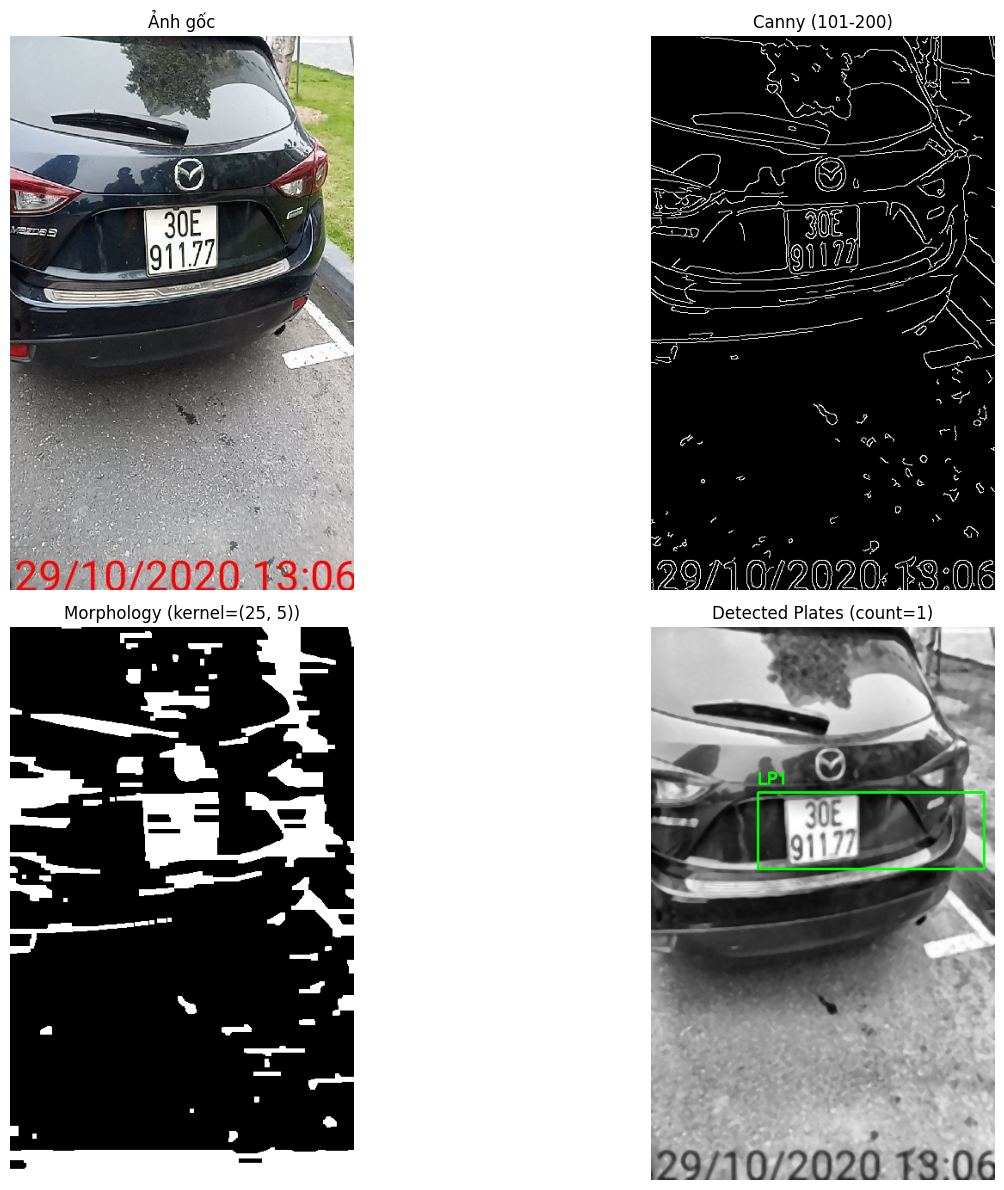

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def auto_canny(image, sigma=0.33):
    """Tính tự động Canny thresholds dựa trên median pixel value."""
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return lower, upper

def detect_license_plate_v3_hybrid(image_preprocessed,
                                    sigma=0.33,
                                    area_ratio_range=(0.02, 0.25),  # 2%-25% diện tích ảnh
                                    aspect_ratio_range=(0.8, 3.5),
                                    min_solidity=0.5,
                                    use_fixed_kernel=True,  # Dùng fixed kernel như v2
                                    debug=False):
    """
    Phát hiện biển số - Hybrid: Adaptive Area + Fixed Kernel (v2 proven).
    
    Args:
        image_preprocessed: Ảnh grayscale đã tiền xử lý (CLAHE)
        sigma: Hệ số điều chỉnh Canny
        area_ratio_range: % diện tích ảnh (adaptive)
        aspect_ratio_range: Khoảng W/H
        min_solidity: Độ "đặc" tối thiểu
        use_fixed_kernel: True = dùng kernel v2 (25,5), False = adaptive
        debug: In thông tin chi tiết
    
    Returns:
        plates: List[(x, y, w, h)]
        debug_info: Dictionary với intermediate images & stats
    """
    
    img_height, img_width = image_preprocessed.shape
    img_area = img_height * img_width
    
    #  1. ADAPTIVE AREA THRESHOLDS 
    min_area = int(img_area * area_ratio_range[0])
    max_area = int(img_area * area_ratio_range[1])
    
    if debug:
        print(f"📐 Image: {img_width}x{img_height}, area={img_area}")
        print(f"   Area range: {min_area}-{max_area} ({area_ratio_range[0]*100:.1f}%-{area_ratio_range[1]*100:.1f}%)")
    
    #  2. AUTO CANNY 
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma=sigma)
    if debug:
        print(f"📊 Canny: {lower_canny}-{upper_canny}")
    
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    #  3. MORPHOLOGY - FIXED KERNEL (v2 proven) 
    if use_fixed_kernel:
        kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))  # ✓ v2 kernel
        kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        kernel_info = "fixed (25,5)"
        kernel_size = (25, 5)
    else:
        # Fallback: adaptive kernel nhỏ hơn
        kernel_width = max(5, int(img_width * 0.06))  # 6% chiều rộng
        kernel_height = max(3, int(img_height * 0.01))  # 1% chiều cao
        if kernel_width % 2 == 0:
            kernel_width += 1
        if kernel_height % 2 == 0:
            kernel_height += 1
        kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, kernel_height))
        kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        kernel_info = f"adaptive ({kernel_width},{kernel_height})"
        kernel_size = (kernel_width, kernel_height)
    
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    if debug:
        print(f"🔧 Kernel: {kernel_info}")
    
    #  4. FIND CONTOURS 
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    #  5. GEOMETRIC FILTERING 
    plates = []
    rejected_stats = {"area": 0, "aspect_ratio": 0, "solidity": 0, "margin": 0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # Filter 1: Diện tích (adaptive)
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # Filter 2: Tỷ lệ W/H
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # Filter 3: Solidity
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # Filter 4: Margin (adaptive)
        margin = max(3, int(img_width * 0.03))
        if x < margin or y < margin or (x + w) > (img_width - margin) or (y + h) > (img_height - margin):
            rejected_stats["margin"] += 1
            continue
        
        # ✅ Pass all filters
        plates.append((x, y, w, h))
        if debug:
            print(f"  ✓ Area={area:.0f}, AR={aspect_ratio:.2f}, Sol={solidity:.2f}")
    
    #  DEBUG INFO 
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": len(contours),
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "min_area": min_area,
        "max_area": max_area,
        "kernel_close": kernel_size,
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    
    if debug:
        print(f"\n📈 Summary: {len(contours)} contours → {len(plates)} plates")
        print(f"   Rejected - area:{rejected_stats['area']} AR:{rejected_stats['aspect_ratio']} "
              f"solidity:{rejected_stats['solidity']} margin:{rejected_stats['margin']}")
    
    return plates, debug_info

#  TEST 
detected_plates, debug_info = detect_license_plate_v3_hybrid(
    process_images['clahe'],
    area_ratio_range=(0.02, 0.25),  # 2%-25% diện tích ảnh
    use_fixed_kernel=True,          # Dùng kernel v2
    debug=True
)

print(f"\nFound {len(detected_plates)} plates")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: pos=({x}, {y}), size=({w}x{h}), ratio={w/h:.2f}")

#  VISUALIZE 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original
axes[0, 0].imshow(cv2.cvtColor(process_images['original'], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Canny
axes[0, 1].imshow(debug_info['edges'], cmap='gray')
axes[0, 1].set_title(f"Canny ({debug_info['canny_lower']}-{debug_info['canny_upper']})")
axes[0, 1].axis('off')

# Morphology
axes[1, 0].imshow(debug_info['morph'], cmap='gray')
axes[1, 0].set_title(f"Morphology (kernel={debug_info['kernel_close']})")
axes[1, 0].axis('off')

# Result
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for idx, (x, y, w, h) in enumerate(detected_plates):
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP{idx+1}", (x, y-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## So sánh và biểu đồ của những phiên bản
---

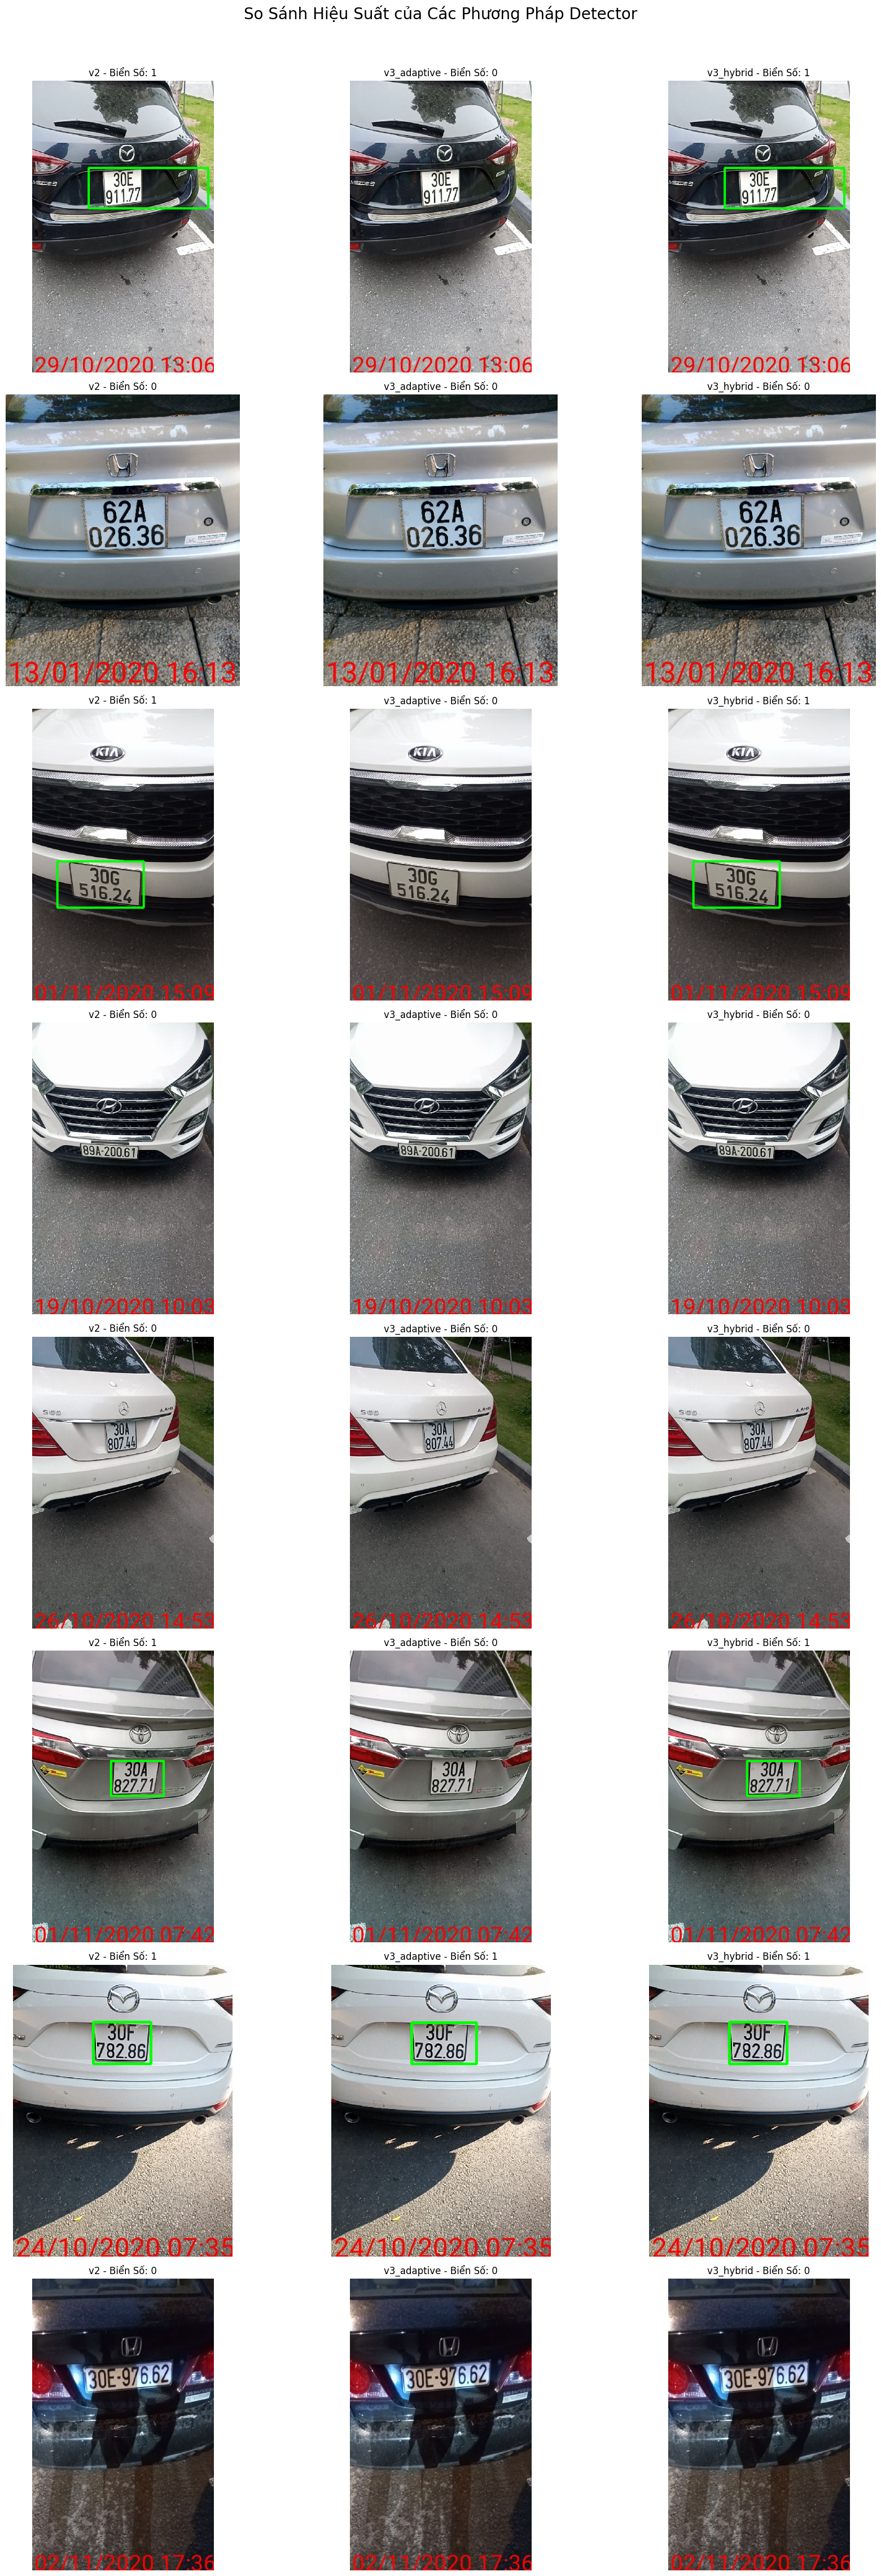

In [47]:
# SO SÁNH CÁC PHIÊN BẢN

# Các hàm detector để so sánh:
detectors_to_compare = {
    "v2": detect_license_plate_v2,
    "v3_adaptive": detect_license_plate_v3,
    "v3_hybrid": detect_license_plate_v3_hybrid
}

# Danh sách đường dẫn ảnh để kiểm tra (8)
comparison_image_paths = [
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_91177_checkin_2020-10-29-13-6OyGuWtJecr.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AEONTP_62A02636_checkin_2020-1-13-16-14gXI_gF3J5Z.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-11-1-15-93yek_xsMxg.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-10-19-10-3VNDtBDGikR.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_80744_checkin_2020-10-26-14-54dqRyEOofRo.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_82771_checkin_2020-11-1-7-42qzNT0orBVD.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_78286_checkoutex_2020-10-24-7-35_t4_Sdhb7B.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_97662_checkin_2020-11-2-17-37AU9BTVtt4r.jpg'
]

# Thiết lập biểu đồ và chạy so sánh
num_images = len(comparison_image_paths)
num_detectors = len(detectors_to_compare)
fig, axes = plt.subplots(num_images, num_detectors, figsize=(18, 6 * num_images))
fig.suptitle('So Sánh Hiệu Suất của Các Phương Pháp Detector', fontsize=20)

if num_images == 1: axes = axes.reshape(1, -1)  

for i, image_path in enumerate(comparison_image_paths):
    # Tiền xử lý ảnh
    processed_imgs = load_and_preprocess(image_path)
    if not processed_imgs:
        print(f"Lỗi tải ảnh: {image_path}")
        continue
    
    clahe_img = processed_imgs['clahe']
    original_img = processed_imgs['original']
    
    for j, (detector_name, detector_func) in enumerate(detectors_to_compare.items()):
        # Chạy detector
        detected_plates, _ = detector_func(clahe_img, debug=False)
        
        # Vẽ hộp giới hạn trên ảnh gốc
        result_image = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        for (x, y, w, h) in detected_plates:
            cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 3)
        
        # Hiển thị kết quả
        ax = axes[i, j]
        ax.imshow(result_image)
        ax.set_title(f"{detector_name} - Biển Số: {len(detected_plates)}")
        ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

✓ Đã thu thập dữ liệu từ 24 tổ hợp detector-image
Loại dữ liệu:
Image                   object
Detector                object
Plates_Found             int64
Total_Contours           int64
Rejected_Area            int64
Rejected_AspectRatio     int64
Rejected_Solidity        int64
Rejected_Margin          int64
dtype: object



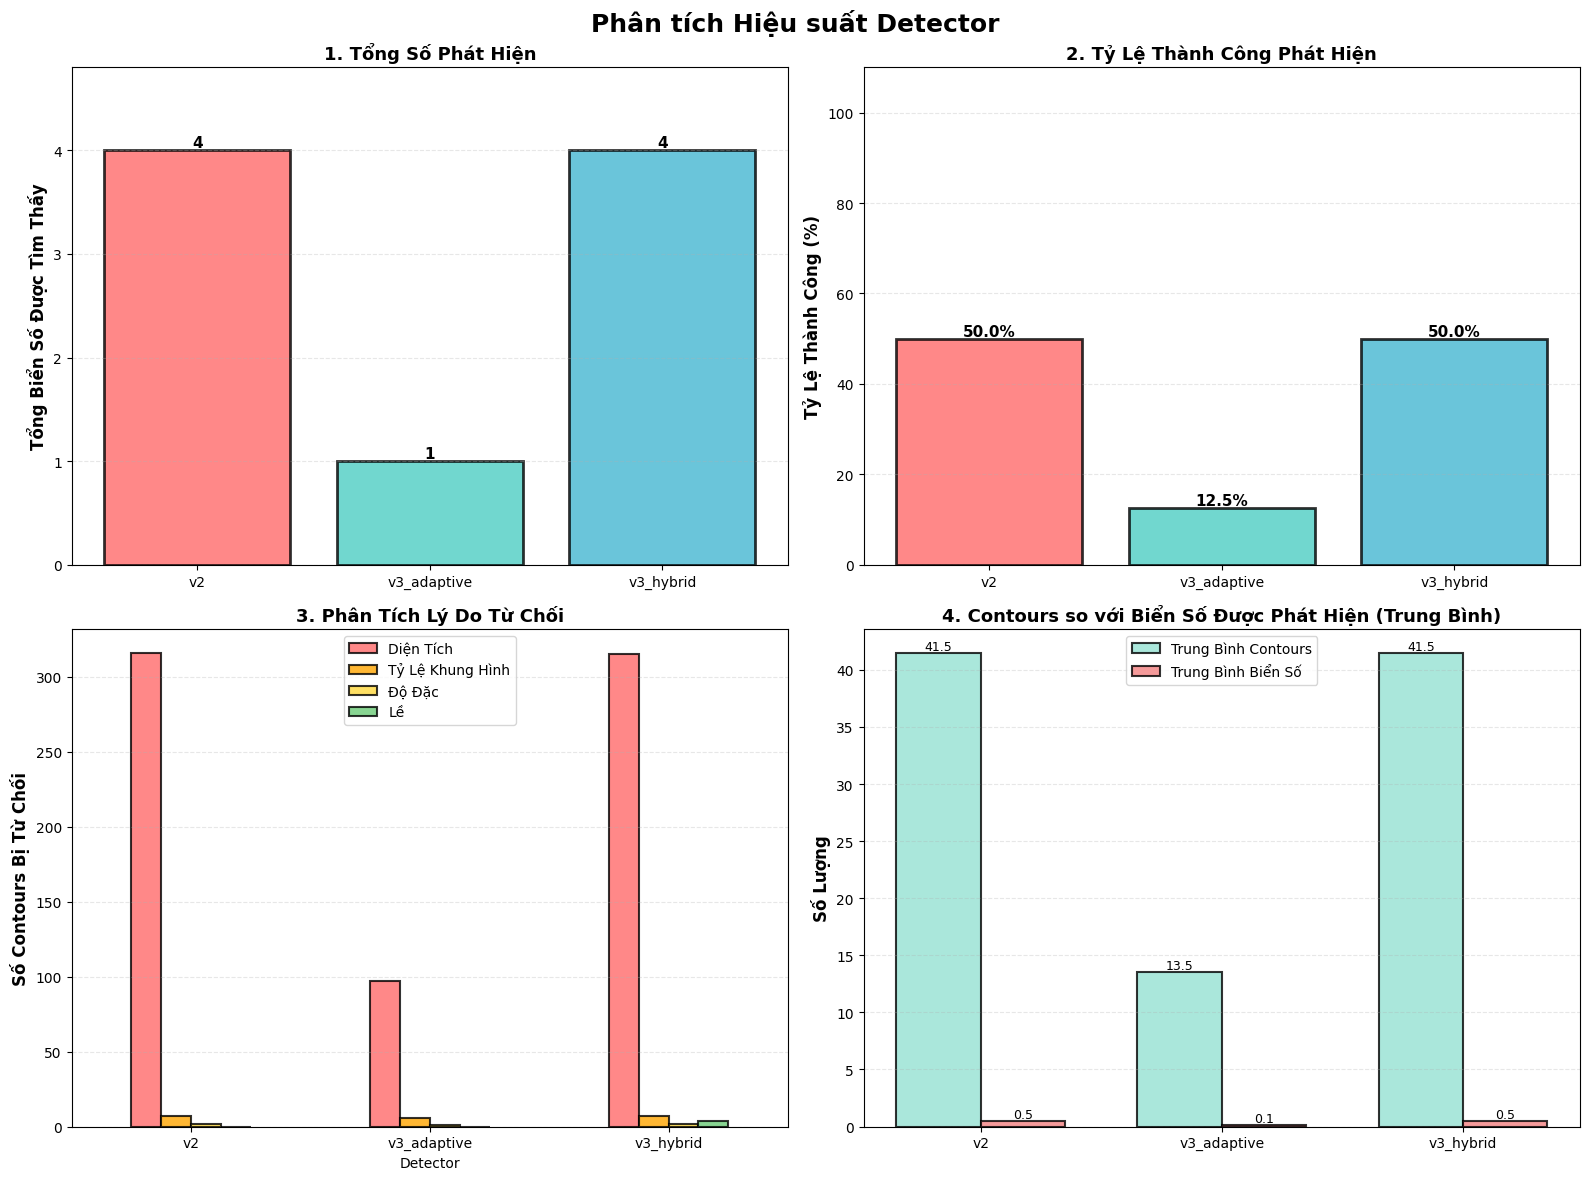

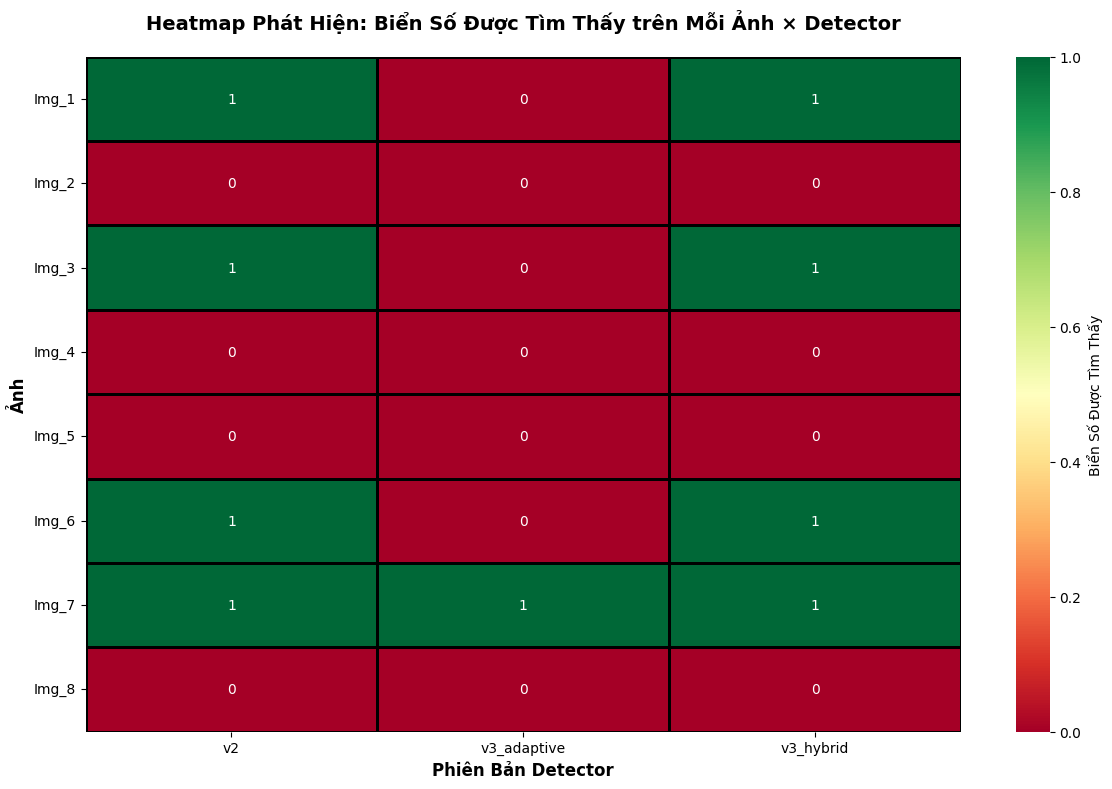

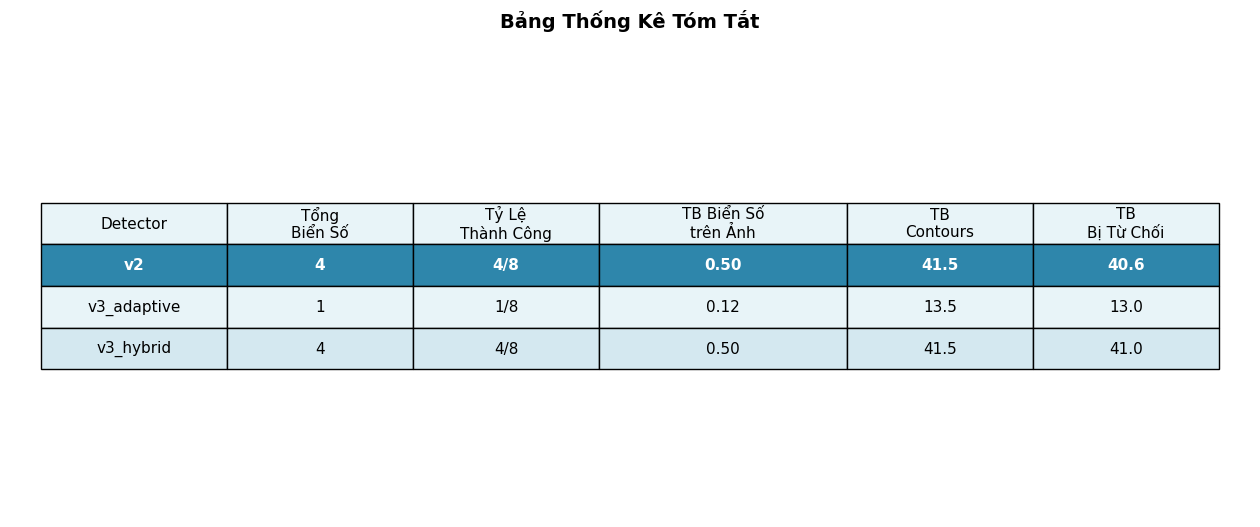


PHÂN TÍCH CHI TIẾT

V2:
   • Tổng biển số được tìm thấy: 4
   • Tỷ lệ thành công: 4/8 (50.0%)
   • Trung bình biển số trên mỗi ảnh: 0.50
   • Trung bình contours được tìm thấy: 41.5
   • Tổng số lần từ chối:
      - Diện tích: 316
      - Tỷ lệ khung hình: 7
      - Độ đặc: 2
      - Lề: 0

V3_ADAPTIVE:
   • Tổng biển số được tìm thấy: 1
   • Tỷ lệ thành công: 1/8 (12.5%)
   • Trung bình biển số trên mỗi ảnh: 0.12
   • Trung bình contours được tìm thấy: 13.5
   • Tổng số lần từ chối:
      - Diện tích: 97
      - Tỷ lệ khung hình: 6
      - Độ đặc: 1
      - Lề: 0

V3_HYBRID:
   • Tổng biển số được tìm thấy: 4
   • Tỷ lệ thành công: 4/8 (50.0%)
   • Trung bình biển số trên mỗi ảnh: 0.50
   • Trung bình contours được tìm thấy: 41.5
   • Tổng số lần từ chối:
      - Diện tích: 315
      - Tỷ lệ khung hình: 7
      - Độ đặc: 2
      - Lề: 4



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========== LẬP THỐNG KÊ DỮ LIỆU MỚI ==========
results_data = []

for i, image_path in enumerate(comparison_image_paths):
    processed_imgs = load_and_preprocess(image_path)
    if not processed_imgs:
        continue
    
    clahe_img = processed_imgs['clahe']
    original_img = processed_imgs['original']
    image_name = f"Img_{i+1}"  # Sử dụng đánh số để tránh trùng lặp
    
    for detector_name, detector_func in detectors_to_compare.items():
        plates, debug_info = detector_func(clahe_img, debug=False)
        
        # Đảm bảo Total_Contours được lưu trữ dưới dạng INT, không phải tuple
        total_contours = debug_info['contours']
        if isinstance(total_contours, tuple):
            total_contours = len(total_contours)
        
        results_data.append({
            'Image': image_name,
            'Detector': detector_name,
            'Plates_Found': len(plates),
            'Total_Contours': int(total_contours),
            'Rejected_Area': debug_info['rejected'].get('area', 0),
            'Rejected_AspectRatio': debug_info['rejected'].get('aspect_ratio', 0),
            'Rejected_Solidity': debug_info['rejected'].get('solidity', 0),
            'Rejected_Margin': debug_info['rejected'].get('margin', 0),
        })

# Chuyển đổi sang DataFrame để phân tích 
df_results = pd.DataFrame(results_data)
print(f"✓ Đã thu thập dữ liệu từ {len(df_results)} tổ hợp detector-image")
print(f"Loại dữ liệu:\n{df_results.dtypes}\n")

# ========== BIỂU ĐỒ 1: TỶ LỆ THÀNH CÔNG THEO DETECTOR ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân tích Hiệu suất Detector', fontsize=18, fontweight='bold')

# Biểu đồ 1.1: Tổng số biển số được tìm thấy theo detector
ax1 = axes[0, 0]
plates_by_detector = df_results.groupby('Detector')['Plates_Found'].sum()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars1 = ax1.bar(plates_by_detector.index, plates_by_detector.values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Tổng Biển Số Được Tìm Thấy', fontsize=12, fontweight='bold')
ax1.set_title('1. Tổng Số Phát Hiện', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(plates_by_detector.values) * 1.2)
# Thêm nhãn giá trị trên các thanh
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Biểu đồ 1.2: Tỷ lệ thành công (ảnh có ít nhất 1 biển số được phát hiện)
ax2 = axes[0, 1]
success_rates = df_results.groupby('Detector')['Plates_Found'].apply(
    lambda x: (x > 0).sum() / len(x) * 100
)
bars2 = ax2.bar(success_rates.index, success_rates.values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('Tỷ Lệ Thành Công (%)', fontsize=12, fontweight='bold')
ax2.set_title('2. Tỷ Lệ Thành Công Phát Hiện', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 110)
# Thêm nhãn giá trị trên các thanh
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Biểu đồ 2: Phân tích lý do từ chối
ax3 = axes[1, 0]
rejection_reasons = df_results.groupby('Detector')[['Rejected_Area', 'Rejected_AspectRatio', 'Rejected_Solidity', 'Rejected_Margin']].sum()
rejection_reasons.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#FFA500', '#FFD93D', '#6BCB77'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Số Contours Bị Từ Chối', fontsize=12, fontweight='bold')
ax3.set_title('3. Phân Tích Lý Do Từ Chối', fontsize=13, fontweight='bold')
ax3.legend(['Diện Tích', 'Tỷ Lệ Khung Hình', 'Độ Đặc', 'Lề'], loc='upper center', fontsize=10)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Biểu đồ 3: Trung bình contours so với biển số được phát hiện
ax4 = axes[1, 1]
contour_stats = df_results.groupby('Detector')[['Total_Contours', 'Plates_Found']].mean()
x = np.arange(len(contour_stats.index))
width = 0.35
bars_contours = ax4.bar(x - width/2, contour_stats['Total_Contours'], width, label='Trung Bình Contours', color='#95E1D3', alpha=0.8, edgecolor='black', linewidth=1.5)
bars_plates = ax4.bar(x + width/2, contour_stats['Plates_Found'], width, label='Trung Bình Biển Số', color='#F38181', alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Số Lượng', fontsize=12, fontweight='bold')
ax4.set_title('4. Contours so với Biển Số Được Phát Hiện (Trung Bình)', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(contour_stats.index)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
# Thêm nhãn giá trị
for bars in [bars_contours, bars_plates]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ========== BIỂU ĐỒ 2: HEATMAP - HIỆU SUẤT DETECTOR TRÊN MỖI ẢNH ==========
fig, ax = plt.subplots(figsize=(12, 8))

# Bảng pivot: Ảnh × Detector với số biển số được phát hiện
heatmap_data = df_results.pivot_table(index='Image', columns='Detector', values='Plates_Found', aggfunc='first')

# Tạo heatmap
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='RdYlGn', cbar_kws={'label': 'Biển Số Được Tìm Thấy'}, 
            linewidths=2, linecolor='black', ax=ax, vmin=0, vmax=heatmap_data.max().max())
ax.set_title('Heatmap Phát Hiện: Biển Số Được Tìm Thấy trên Mỗi Ảnh × Detector', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Phiên Bản Detector', fontsize=12, fontweight='bold')
ax.set_ylabel('Ảnh', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ========== BIỂU ĐỒ 3: BẢNG SO SÁNH CHI TIẾT ==========
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')

# Tạo bảng tóm tắt
summary_data = []
for detector in detectors_to_compare.keys():
    detector_df = df_results[df_results['Detector'] == detector]
    summary_data.append([
        detector,
        f"{detector_df['Plates_Found'].sum():.0f}",
        f"{(detector_df['Plates_Found'] > 0).sum()}/{len(detector_df)}",
        f"{detector_df['Plates_Found'].mean():.2f}",
        f"{detector_df['Total_Contours'].mean():.1f}",
        f"{detector_df[['Rejected_Area', 'Rejected_AspectRatio', 'Rejected_Solidity', 'Rejected_Margin']].sum(axis=1).mean():.1f}",
    ])

table = ax.table(cellText=summary_data,
                colLabels=['Detector', 'Tổng\nBiển Số', 'Tỷ Lệ\nThành Công', 'TB Biển Số\ntrên Ảnh', 'TB\nContours', 'TB\nBị Từ Chối'],
                cellLoc='center',
                loc='center',
                colWidths=[0.15, 0.15, 0.15, 0.2, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Định dạng tiêu đề
for i in range(len(table.get_children())):
    cell = table.get_children()[i]
    if i < 6:  # Hàng tiêu đề
        cell.set_facecolor('#2E86AB')
        cell.set_text_props(weight='bold', color='white')
    else:
        if (i - 6) // 6 % 2 == 0:
            cell.set_facecolor('#E8F4F8')
        else:
            cell.set_facecolor('#D4E8F0')

plt.title('Bảng Thống Kê Tóm Tắt', fontsize=14, fontweight='bold', pad=20)
plt.show()

# ========== IN RA CÁC THÔNG TIN CHI TIẾT ==========
print("\n" + "="*80)
print("PHÂN TÍCH CHI TIẾT")
print("="*80)

for detector in detectors_to_compare.keys():
    detector_df = df_results[df_results['Detector'] == detector]
    print(f"\n{detector.upper()}:")
    print(f"   • Tổng biển số được tìm thấy: {detector_df['Plates_Found'].sum()}")
    print(f"   • Tỷ lệ thành công: {(detector_df['Plates_Found'] > 0).sum()}/{len(detector_df)} ({(detector_df['Plates_Found'] > 0).sum() / len(detector_df) * 100:.1f}%)")
    print(f"   • Trung bình biển số trên mỗi ảnh: {detector_df['Plates_Found'].mean():.2f}")
    print(f"   • Trung bình contours được tìm thấy: {detector_df['Total_Contours'].mean():.1f}")
    print(f"   • Tổng số lần từ chối:")
    print(f"      - Diện tích: {detector_df['Rejected_Area'].sum()}")
    print(f"      - Tỷ lệ khung hình: {detector_df['Rejected_AspectRatio'].sum()}")
    print(f"      - Độ đặc: {detector_df['Rejected_Solidity'].sum()}")
    print(f"      - Lề: {detector_df['Rejected_Margin'].sum()}")

print("\n" + "="*80)

# Bước 4: Chuẩn hóa và phân tách ký tự (Segmentation)

## Chuyển biển số sang ảnh nhị phân **(Otsu Threshold)**


✓ Cắt vùng biển số: vị trí=(124, 193), kích thước=(263x89)
📊 Otsu Threshold Value: 141.0
✅ Morphological operations applied
 Ảnh biển số: (89, 263, 3)
 Phương pháp nhị phân hóa: otsu


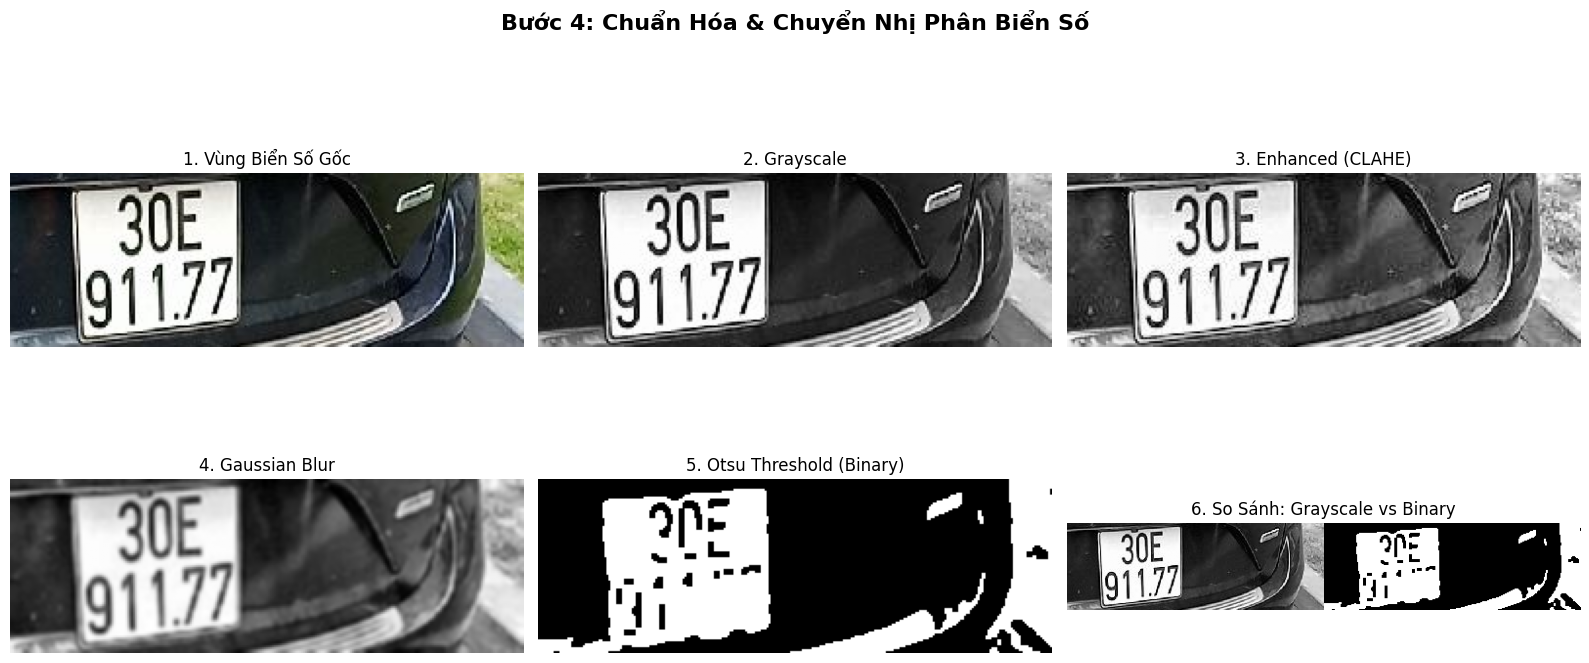


✅ Binarization thành công!
   Input shape: (89, 263, 3)
   Output shape: (89, 263)
   Pixel trắng (foreground): 8438 / 23407
   Pixel đen (background): 14969 / 23407


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def binarize_license_plate(plate_roi, method='otsu', debug=False):
    """
    Chuyển vùng biển số sang ảnh nhị phân để chuẩn bị phân tách ký tự.
    
    Args:
        plate_roi: Vùng biển số được cắt từ ảnh gốc (BGR hoặc grayscale)
        method: 'otsu' (mặc định) hoặc 'adaptive'
        debug: In thông tin chi tiết
    
    Returns:
        binary_plate: Ảnh nhị phân
        preprocessed_plate: Ảnh grayscale sau tiền xử lý (trước binarization)
        debug_info: Dictionary chứa intermediate images
    """
    
    # 1. Chuyển sang grayscale nếu biển số là ảnh màu
    if len(plate_roi.shape) == 3: gray_plate = cv2.cvtColor(plate_roi, cv2.COLOR_BGR2GRAY)
    else: gray_plate = plate_roi
    
    # 2. Áp dụng CLAHE để tăng cường độ tương phản
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_plate = clahe.apply(gray_plate)
    
    # 3. Áp dụng Gaussian Blur để giảm nhiễu
    blurred_plate = cv2.GaussianBlur(enhanced_plate, (5, 5), 0)
    
    # 4. Binarization - Otsu Threshold 
    if method == 'otsu':
        threshold_value, binary_plate = cv2.threshold(
            blurred_plate, 0, 255, 
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        if debug:
            print(f"📊 Otsu Threshold Value: {threshold_value}")
    elif method == 'adaptive':
        binary_plate = cv2.adaptiveThreshold(
            blurred_plate, 255, 
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY, 
            11, 2
        )
        if debug:
            print("📊 Adaptive Thresholding applied")
    else:
        raise ValueError("Phương pháp không hợp lệ. Chọn 'otsu' hoặc 'adaptive'.")
    
    # 5. Morphological Operations để làm sạch ảnh nhị phân
    # Phép đóng: nối các vùng trắng liền kề  
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary_plate = cv2.morphologyEx(binary_plate, cv2.MORPH_CLOSE, kernel_close)

    # Phép mở: loại bỏ nhiễu nhỏ
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    binary_plate = cv2.morphologyEx(binary_plate, cv2.MORPH_OPEN, kernel_open)
    
    if debug:
        print("✅ Morphological operations applied")
    
    # Debug info
    debug_info = {
        "gray_plate": gray_plate,
        "enhanced_plate": enhanced_plate,
        "blurred_plate": blurred_plate,
        "binary_plate": binary_plate
    }
    
    if debug:
        print(f" Ảnh biển số: {plate_roi.shape}")
        print(f" Phương pháp nhị phân hóa: {method}")
        
    return binary_plate, blurred_plate, debug_info
    
# ========= TEST & VISUALIZE Binarization ==========
detect_plates, debug_info_detect = detect_license_plate_v3_hybrid(
    process_images['clahe'],
    use_fixed_kernel=True,
    debug=False
)
if len(detect_plates) > 0:
    # Lấy vùng biển số đầu tiên
    x, y, w, h = detect_plates[0]
    plate_roi = process_images['original'][y:y+h, x:x+w]
    
    print(f"\n✓ Cắt vùng biển số: vị trí=({x}, {y}), kích thước=({w}x{h})")
    
    # Binarize vùng biển số
    binary_plate, preprocessed_plate, debug_info_binarize_otsu = binarize_license_plate(
        plate_roi,
        method='otsu',
        debug=True
    )
    
    # Hiển thị kết quả
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle('Bước 4: Chuẩn Hóa & Chuyển Nhị Phân Biển Số', fontsize=16, fontweight='bold')
    
    # Original plate
    axes[0, 0].imshow(cv2.cvtColor(plate_roi, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('1. Vùng Biển Số Gốc')
    axes[0, 0].axis('off')
    
    # Grayscale
    axes[0, 1].imshow(debug_info_binarize_otsu['gray_plate'], cmap='gray')
    axes[0, 1].set_title('2. Grayscale')
    axes[0, 1].axis('off')
    
    # Enhanced (CLAHE)
    axes[0, 2].imshow(debug_info_binarize_otsu['enhanced_plate'], cmap='gray')
    axes[0, 2].set_title('3. Enhanced (CLAHE)')
    axes[0, 2].axis('off')
    
    # Blurred
    axes[1, 0].imshow(debug_info_binarize_otsu['blurred_plate'], cmap='gray')
    axes[1, 0].set_title('4. Gaussian Blur')
    axes[1, 0].axis('off')
    
    # Binary (Otsu)
    axes[1, 1].imshow(debug_info_binarize_otsu['binary_plate'], cmap='gray')
    axes[1, 1].set_title('5. Otsu Threshold (Binary)')
    axes[1, 1].axis('off')
    
    # Side-by-side: Original vs Binary
    comparison = np.hstack([debug_info_binarize_otsu['gray_plate'], debug_info_binarize_otsu['binary_plate']])
    axes[1, 2].imshow(comparison, cmap='gray')
    axes[1, 2].set_title('6. So Sánh: Grayscale vs Binary')
    axes[1, 2].axis('off')
    
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Binarization thành công!")
    print(f"   Input shape: {plate_roi.shape}")
    print(f"   Output shape: {binary_plate.shape}")
    print(f"   Pixel trắng (foreground): {np.sum(binary_plate == 255)} / {binary_plate.size}")
    print(f"   Pixel đen (background): {np.sum(binary_plate == 0)} / {binary_plate.size}")
else:
    print("⚠️ Không tìm thấy vùng biển số để cắt và binarize.")
    

## So sánh Adaptive vs Otsu threshold